# Chapter 4 — Results Production Notebook

This notebook orchestrates all figures and tables for the restructured Chapter 4.  
Each section mirrors the thesis structure. Run cells individually to iterate on specific figures.

**Structure:**
- §4.1 Corpus Overview and Register Distinctiveness
- §4.2 Lexical Patterns Across Registers (keyness, exclusivity, co-occurrence)
- §4.3 Thematic Structure: STM
- §4.4 Interpretive Synthesis: H1a–H1c with Close Reading

**Prerequisites:** All pipeline scripts (00–03b) must have been run. Database `scraping_2.db` must be populated.

In [1]:
# ── Imports and Setup ──────────────────────────────────────────────────────
import sqlite3
import json
import math
import textwrap
from pathlib import Path
from collections import Counter, defaultdict

import numpy as np
import pandas as pd
import matplotlib
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import matplotlib.gridspec as gridspec

try:
    import seaborn as sns
    sns.set_style('whitegrid')
except ImportError:
    pass

try:
    import networkx as nx
    _HAS_NX = True
except ImportError:
    _HAS_NX = False
    print('WARNING: networkx not installed — topic network figure will be skipped')

%matplotlib inline
plt.rcParams['figure.dpi'] = 150
plt.rcParams['savefig.dpi'] = 300
plt.rcParams['font.family'] = 'serif'

In [3]:
# ── Configuration ──────────────────────────────────────────────────────────

DB_PATH = '../data/scraping_2.db'        # adjust if needed
FIG_DIR = Path('../output/chapter4/')     # all Chapter 4 figures saved here
FIG_DIR.mkdir(parents=True, exist_ok=True)

DPI_PUB = 300
DPI_EXP = 150
FIG_FORMAT = 'pdf'   # 'pdf' for vector (thesis), 'png' for quick preview

# ── Colour Palette (consistent across all figures) ─────────────────────────
C_CLIENT  = '#1B4F8A'   # deep blue  — client (B2B)
C_WORKER  = '#C0392B'   # deep red   — worker (B2W)
C_SHARED  = '#6C757D'   # grey       — shared / neutral
C_H1C     = '#E67E22'   # orange     — H1c (strategic hypervisibility)
C_GRID    = '#DEE2E6'
C_TEXT    = '#1A1A2E'

PAL_HYP = {
    'H1a': C_WORKER,
    'H1b': C_CLIENT,
    'H1c': C_H1C,
    None:  C_SHARED,
}

# ── Database connection ────────────────────────────────────────────────────
conn = sqlite3.connect(DB_PATH)
conn.row_factory = sqlite3.Row

# Quick check: which tables exist?
tables = {r[0] for r in conn.execute(
    "SELECT name FROM sqlite_master WHERE type IN ('table','view')"
).fetchall()}
print('Available tables/views:', sorted(tables))

# ── Co-occurrence boilerplate / artefact filter ────────────────────────────
# The simplest possible defence against boilerplate-driven PMI spikes.
# Any collocate in this set is excluded *post-query* from co-occurrence
# profiles. Add terms here as they surface in diagnostics.
#
#   cc0         : appears only in the 11 near-duplicate HITL dataset-release
#                 pages ("dedicate public domain human cc0 license"). Pure
#                 boilerplate; not a substantive client-side discourse.
#   fellowship  : HITL footer artefact, same cluster of pages.
#   rat         : lemmatiser truncation of "rate"/"rating". Preprocessing
#                 artefact, not a real collocate.
#   introduc    : lemmatiser truncation of "introduce".
#
# If a term is genuinely interesting across domains, do not add it here.
COOC_BLOCKLIST = {
    'cc0', 'fellowship', 'rat', 'introduc',
}

# Minimum number of distinct domains a (focus, collocate) pair must appear
# across before we plot it. This is the structural version of the filter:
# a real cross-platform pattern should not rely on one domain's boilerplate.
# Set to 1 to disable the structural filter (blocklist alone will then carry
# all the weight); set to 3 for a stricter cross-platform criterion.
COOC_MIN_DOMAINS = 3


Available tables/views: ['_corpus_view_backup', 'aggregate_distance', 'cooccurrence_results', 'corpus_view', 'distinctiveness_matrix', 'document_topics', 'domain_quality', 'excluded_pages', 'excluded_terms', 'keyness_results', 'lda_diagnostics', 'links', 'page_audience_override', 'pages', 'pages_embedding', 'pages_tfidf', 'platform_term_counts', 'platforms', 'sqlite_sequence', 'step2_sample', 'stm_content', 'stm_prevalence', 'stm_theta', 'stm_topic_profile', 'stm_topic_terms', 'term_exclusivity', 'topic_audience_profile', 'topic_terms', 'websites']


In [4]:
# ── Helper functions ───────────────────────────────────────────────────────

def save_fig(fig, name, fmt=FIG_FORMAT, dpi=DPI_PUB):
    """Save figure to FIG_DIR with consistent settings."""
    path = FIG_DIR / f'{name}.{fmt}'
    fig.savefig(str(path), dpi=dpi, bbox_inches='tight', facecolor='white')
    print(f'  Saved: {path}')

def apply_style(ax):
    """Apply consistent thesis style to an axis."""
    ax.spines['top'].set_visible(False)
    ax.spines['right'].set_visible(False)
    ax.spines['left'].set_color(C_GRID)
    ax.spines['bottom'].set_color(C_GRID)
    ax.tick_params(colors=C_TEXT, labelsize=9)
    ax.set_axisbelow(True)

def to_latex_table(df, caption, label, note='', fmt_cols=None):
    """Convert a DataFrame to a thesis-ready LaTeX tabular string."""
    lines = []
    lines.append(r'\begin{table}[ht]')
    lines.append(r'  \centering')
    lines.append(f'  \\caption{{{caption}}}')
    lines.append(f'  \\label{{{label}}}')
    lines.append(r'  \small')
    col_fmt = 'l' + 'r' * (len(df.columns) - 1)
    lines.append(f'  \\begin{{tabular}}{{{col_fmt}}}')
    lines.append(r'    \toprule')
    headers = ' & '.join(str(c) for c in df.columns) + r' \\'
    lines.append(f'    {headers}')
    lines.append(r'    \midrule')
    for _, row in df.iterrows():
        vals = ' & '.join(str(v) for v in row.values) + r' \\'
        lines.append(f'    {vals}')
    lines.append(r'    \bottomrule')
    lines.append(r'  \end{tabular}')
    if note:
        lines.append(r'  \begin{tablenotes}')
        lines.append(r'    \small')
        lines.append(f'    \\item \\textit{{Note.}} {note}')
        lines.append(r'  \end{tablenotes}')
    lines.append(r'\end{table}')
    return '\n'.join(lines)

---
## §4.1 — Corpus Overview and Register Distinctiveness

In [7]:
# ── §4.1.1: Corpus composition stats ──────────────────────────────────────
# These numbers go directly into the text of §4.1

stats = pd.read_sql("""
    SELECT
        audience,
        COUNT(DISTINCT domain) AS n_platforms,
        COUNT(*)               AS n_pages,
        SUM(token_count)       AS total_tokens
    FROM corpus_view
    WHERE page_id NOT IN (SELECT page_id FROM excluded_pages)
      AND audience != 'both'
    GROUP BY audience
""", conn)

total_pages = stats['n_pages'].sum()
stats['pct'] = (stats['n_pages'] / total_pages * 100).round(1)

print('=== Corpus Composition ===')
print(stats.to_string(index=False))
print(f'\nTotal pages (excl. both): {total_pages}')

=== Corpus Composition ===
audience  n_platforms  n_pages  total_tokens  pct
  client           23     6692       4621454 88.8
  worker           14      843        730306 11.2

Total pages (excl. both): 7535


In [8]:
# ── §4.1.2: Lexical diversity (TTR) ───────────────────────────────────────

ttr = pd.read_sql("""
    SELECT
        audience,
        SUM(token_count) AS total_tokens,
        COUNT(*) AS n_pages
    FROM corpus_view
    WHERE page_id NOT IN (SELECT page_id FROM excluded_pages)
      AND audience != 'both'
    GROUP BY audience
""", conn)

# Unique tokens need to be computed from the actual unigram lists
for aud in ['worker', 'client']:
    rows = conn.execute("""
        SELECT unigrams FROM corpus_view
        WHERE audience = ? AND page_id NOT IN (SELECT page_id FROM excluded_pages)
    """, (aud,)).fetchall()
    all_terms = set()
    for r in rows:
        if r[0]:
            tokens = json.loads(r[0]) if isinstance(r[0], str) else r[0]
            if isinstance(tokens, list):
                all_terms.update(tokens)
            elif isinstance(tokens, dict):
                all_terms.update(tokens.keys())
    mask = ttr['audience'] == aud
    ttr.loc[mask, 'unique_tokens'] = len(all_terms)

ttr['ttr'] = ttr['unique_tokens'] / ttr['total_tokens']

print('=== Lexical Diversity ===')
print(ttr.to_string(index=False))

=== Lexical Diversity ===
audience  total_tokens  n_pages  unique_tokens      ttr
  client       4621454     6692        40704.0 0.008808
  worker        730306      843        27486.0 0.037636


In [9]:
# ── §4.1.3: Aggregate JSD and Cosine ──────────────────────────────────────
# These values were computed by 02_step1_analysis.py section E
# and may be stored in the DB or printed to stdout during that run.
# Check if they're in a table:

if 'aggregate_distance' in tables:
    agg = pd.read_sql('SELECT * FROM aggregate_distance', conn)
    print(agg)
elif 'distinctiveness_matrix' in tables:
    # Compute from the pairwise matrix
    print('aggregate_distance table not found.')
    print('Computing from distinctiveness_matrix...')
    # TODO: compute aggregate JSD between all-client vs all-worker vectors
    print('ACTION NEEDED: add aggregate computation here or extract from script logs')
else:
    print('Neither aggregate_distance nor distinctiveness_matrix found in DB.')
    print('Run 02_step1_analysis.py first.')

   id                comparison       jsd  cosine_sim  n_client_tokens  \
0   1  cross_platform_aggregate  0.194251    0.766479          3371522   

   n_worker_tokens           created_at  
0           702135  2026-03-27 12:45:47  


/Users/yannickkayser/Uni/Master/Master_Thesis/DarkSideofAI/venv-plot/lib/python3.10/site-packages/sklearn/manifold/_mds.py:677: FutureWarning: The default value of `n_init` will change from 4 to 1 in 1.9.
  warnings.warn(


Domains in distance matrix: ['crowdgen.com', 'defined.ai', 'humansintheloop.org', 'imerit.net', 'joinstellar.ai', 'labelbox.com', 'mindrift.ai', 'mindy-support.com', 'outlier.ai', 'remoter.me', 'scale.com', 'toloka.ai', 'www.abaka.ai', 'www.alignerr.com', 'www.appen.com', 'www.centific.com', 'www.cloudfactory.com', 'www.crowdworks.ai', 'www.dataannotation.tech', 'www.digitaldividedata.com', 'www.lxt.ai', 'www.microworkers.com', 'www.oneforma.com', 'www.remotasks.com', 'www.sama.com', 'www.superannotate.com']
Audience map: {'mindrift.ai': 'worker', 'crowdgen.com': 'worker', 'www.appen.com': 'client', 'scale.com': 'client', 'www.remotasks.com': 'worker', 'www.sama.com': 'client', 'toloka.ai': 'client', 'www.lxt.ai': 'client', 'www.clickworker.com': 'worker', 'www.microworkers.com': 'worker', 'www.oneforma.com': 'worker', 'www.dataannotation.tech': 'worker', 'outlier.ai': 'worker', 'www.mturk.com': 'both', 'www.prolific.com': 'worker', 'surgehq.ai': 'client', 'defined.ai': 'client', 'www.

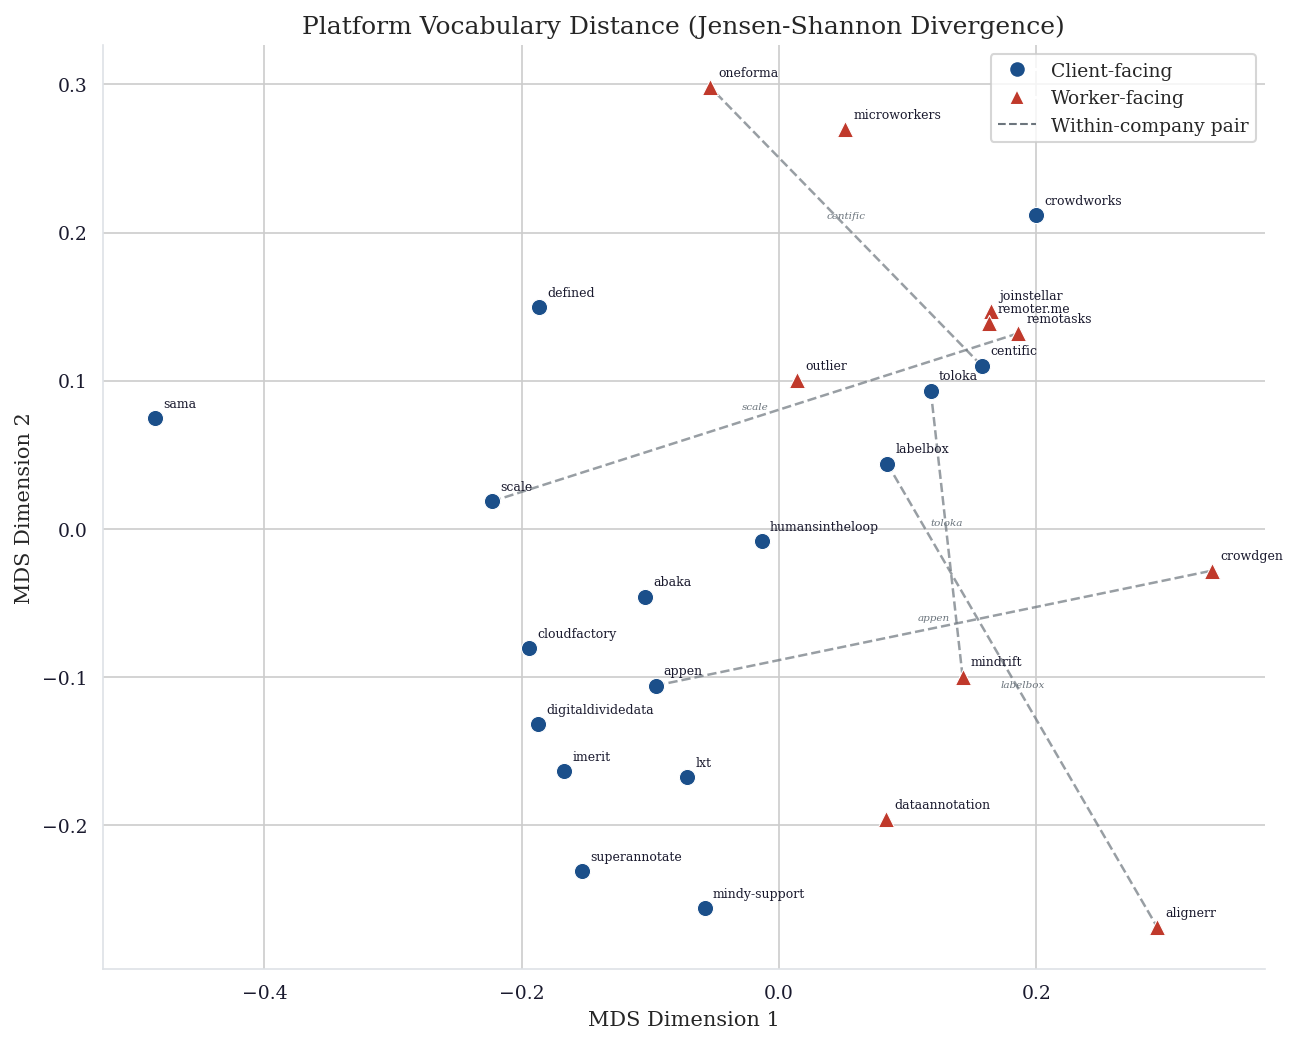


=== Within-company pair JSD distances ===
  www.appen.com ↔ crowdgen.com: JSD = 0.4102
  toloka.ai ↔ mindrift.ai: JSD = 0.2556
  www.centific.com ↔ www.oneforma.com: JSD = 0.3318
  labelbox.com ↔ www.alignerr.com: JSD = 0.4029
  scale.com ↔ www.remotasks.com: JSD = 0.4085


In [14]:
# ── §4.1.4: JSD Platform MDS Map (Figure 4.1) ─────────────────────────────

from sklearn.manifold import MDS

dm = pd.read_sql('SELECT * FROM distinctiveness_matrix', conn)

domains = sorted(set(dm['domain_a']) | set(dm['domain_b']))
n = len(domains)
d_idx = {d: i for i, d in enumerate(domains)}
dist = np.zeros((n, n))
for _, row in dm.iterrows():
    i, j = d_idx[row['domain_a']], d_idx[row['domain_b']]
    dist[i, j] = dist[j, i] = row['jsd']

mds = MDS(n_components=2, dissimilarity='precomputed', random_state=42,
          normalized_stress='auto')
coords = mds.fit_transform(dist)

aud_map = dict(conn.execute("""
    SELECT DISTINCT domain, audience FROM corpus_view
    WHERE page_id NOT IN (SELECT page_id FROM excluded_pages)
""").fetchall())

# ── FIX: Print actual domain names so you can verify the pairs ────────────
print("Domains in distance matrix:", sorted(domains))
print("Audience map:", aud_map)

# ── FIX: Within-company pairs using fuzzy matching ────────────────────────
# Define pairs by a recognisable substring — the script finds the actual
# domain string in the distance matrix that contains it.

PAIR_HINTS = [
    ('appen',     'crowdgen'),
    ('toloka',    'mindrift'),
    ('centific',  'oneforma'),
    ('labelbox',  'alignerr'),
    ('scale',     'remotasks'),
]

def find_domain(hint, domain_list):
    """Find the domain in domain_list that contains the hint substring."""
    matches = [d for d in domain_list if hint in d.lower()]
    if len(matches) == 1:
        return matches[0]
    elif len(matches) > 1:
        # Prefer shorter match (e.g., 'scale' matches 'scale' not 'scale-something')
        return min(matches, key=len)
    return None

PAIRS = []
for h1, h2 in PAIR_HINTS:
    d1 = find_domain(h1, domains)
    d2 = find_domain(h2, domains)
    if d1 and d2:
        PAIRS.append((d1, d2))
        print(f"  Pair matched: {d1} ↔ {d2}")
    else:
        print(f"  ⚠️ Pair NOT matched: {h1}→{d1}, {h2}→{d2}")

# ── Plot ──────────────────────────────────────────────────────────────────

fig, ax = plt.subplots(figsize=(10, 8))

for i, d in enumerate(domains):
    aud = aud_map.get(d, 'unknown')
    color = C_CLIENT if aud == 'client' else C_WORKER if aud == 'worker' else C_SHARED
    marker = 'o' if aud == 'client' else '^' if aud == 'worker' else 's'
    ax.scatter(coords[i, 0], coords[i, 1], c=color, marker=marker,
               s=60, zorder=3, edgecolors='white', linewidth=0.5)
    ax.annotate(d.replace('www.','').replace('.com','').replace('.ai','')
                 .replace('.net','').replace('.org','').replace('.tech',''),
                (coords[i, 0], coords[i, 1]),
                fontsize=6, color=C_TEXT, ha='left', va='bottom',
                xytext=(4, 4), textcoords='offset points')

# Draw lines for within-company pairs
for d1, d2 in PAIRS:
    i1, i2 = d_idx[d1], d_idx[d2]
    ax.plot([coords[i1, 0], coords[i2, 0]],
            [coords[i1, 1], coords[i2, 1]],
            color=C_SHARED, linewidth=1.2, linestyle='--', alpha=0.7, zorder=1)
    # Label the pair at midpoint
    mx = (coords[i1, 0] + coords[i2, 0]) / 2
    my = (coords[i1, 1] + coords[i2, 1]) / 2
    pair_name = d1.replace('www.','').replace('.com','').split('.')[0]
    ax.annotate(pair_name, (mx, my), fontsize=5, color=C_SHARED,
                ha='center', va='bottom', fontstyle='italic',
                xytext=(0, 3), textcoords='offset points')

legend_elements = [
    plt.Line2D([0], [0], marker='o', color='w', markerfacecolor=C_CLIENT,
               markersize=8, label='Client-facing'),
    plt.Line2D([0], [0], marker='^', color='w', markerfacecolor=C_WORKER,
               markersize=8, label='Worker-facing'),
    plt.Line2D([0], [0], color=C_SHARED, linestyle='--',
               linewidth=1, label='Within-company pair'),
]
ax.legend(handles=legend_elements, loc='upper right', fontsize=9)

apply_style(ax)
ax.set_xlabel('MDS Dimension 1', fontsize=10)
ax.set_ylabel('MDS Dimension 2', fontsize=10)
ax.set_title('Platform Vocabulary Distance (Jensen-Shannon Divergence)',
             fontsize=12)

save_fig(fig, 'fig_41_jsd_platform_map')
plt.show()

# ── Print pair distances for the text ─────────────────────────────────────
print("\n=== Within-company pair JSD distances ===")
for d1, d2 in PAIRS:
    jsd_val = dist[d_idx[d1], d_idx[d2]]
    print(f"  {d1} ↔ {d2}: JSD = {jsd_val:.4f}")

---
## §4.2 — Lexical Patterns Across Registers

### §4.2.1 — Keyness Analysis

In [13]:
# §4.2 — Top 20 worker-facing key terms (cross-platform comparison)
worker_key = pd.read_sql("""
    SELECT term,
           ll_score,
           rel_freq_worker,
           rel_freq_client,
           ROUND(rel_freq_worker / (rel_freq_worker + rel_freq_client), 4) AS exclusivity
    FROM keyness_results
    WHERE comparison = 'cross_platform'
      AND rel_freq_worker > 0
    ORDER BY ll_score ASC        -- most negative = most worker-key
    LIMIT 20
""", conn)


worker_key['ll_score_abs'] = worker_key['ll_score'].abs()
worker_key['ll_score_abs'] = worker_key['ll_score_abs'].round(2)
worker_key['ll_score'] = worker_key['ll_score'].round(2)
worker_key['rel_freq_client'] = worker_key['rel_freq_client'].round(2)
worker_key['rel_freq_worker'] = worker_key['rel_freq_worker'].round(2)
worker_key['exclusivity'] = worker_key['exclusivity'].round(2)

print(worker_key[['term', 'll_score', 'rel_freq_worker', 'rel_freq_client', 'exclusivity']]
       .to_string(index=False))

# Export LaTeX
tex = to_latex_table(
    worker_key,
    caption='Top 20 key terms in the worker-facing sub-corpus ($G^2$, sorted descending). '
            'Freq = relative frequency per million tokens. $E$ = exclusivity index.',
    label='tab:worker-keyterms',
)
Path(FIG_DIR / 'tab_worker_keyterms.tex').write_text(tex)
print(f'\nLaTeX saved to {FIG_DIR}/tab_worker_keyterms.tex')

       term  ll_score  rel_freq_worker  rel_freq_client  exclusivity
      apply -14619.37            10.05             0.76         0.93
     remote -10825.22            10.66             1.61         0.87
    project  -4377.44             9.24             3.02         0.75
    payment  -4375.71             2.39             0.08         0.97
       earn  -4147.71             2.20             0.07         0.97
       work  -3579.27             9.33             3.50         0.73
       code  -3188.29             3.23             0.51         0.86
    account  -2901.98             2.48             0.30         0.89
        pay  -2894.97             2.46             0.29         0.89
        job  -2820.45             3.42             0.68         0.83
      shall  -2727.49             1.69             0.09         0.95
     access  -2587.58             3.85             0.94         0.80
        feb  -2463.55             1.72             0.14         0.93
evaluate_ai  -2424.90             

In [ ]:
# ── §4.2.1b: Top 20 Key Terms — Client-facing ─────────────────────────────

# §4.1 — Top 20 client-facing key terms
client_key = pd.read_sql("""
    SELECT term,
           ll_score,
           rel_freq_worker,
           rel_freq_client,
           ROUND(rel_freq_client / (rel_freq_worker + rel_freq_client), 2) AS exclusivity
    FROM keyness_results
    WHERE comparison = 'cross_platform'
      AND rel_freq_client > 0
    ORDER BY ll_score DESC       -- most positive = most client-key
    LIMIT 20
""", conn).round(2)

print(client_key[['term', 'll_score', 'rel_freq_worker', 'rel_freq_client', 'exclusivity']]
      .to_string(index=False))

tex = to_latex_table(
    client_key,
    caption='Top 20 key terms in the client-facing sub-corpus ($G^2$, sorted descending).',
    label='tab:client-keyterms',
)
Path(FIG_DIR / 'tab_client_keyterms.tex').write_text(tex)
print(f'\nLaTeX saved to {FIG_DIR}/tab_client_keyterms.tex')

            term  ll_score  rel_freq_worker  rel_freq_client  exclusivity
      annotation   7204.02             0.92             8.77         0.90
     description   5537.09             0.34             5.69         0.94
         dataset   4605.84             0.26             4.66         0.95
        duration   4460.33             0.36             4.85         0.93
           image   3009.17             0.82             4.69         0.85
           video   2875.12             0.71             4.31         0.86
          vision   2800.88             0.05             2.45         0.98
          object   2668.37             0.15             2.70         0.95
           datum   2427.98            11.86            20.23         0.63
 computer_vision   2370.24             0.02             1.96         0.99
      autonomous   2247.00             0.06             2.05         0.97
           label   2211.58             0.37             2.92         0.89
datum_annotation   2041.24            

  Saved: ../output/chapter4/fig_42_keyness_diverging_bar.pdf


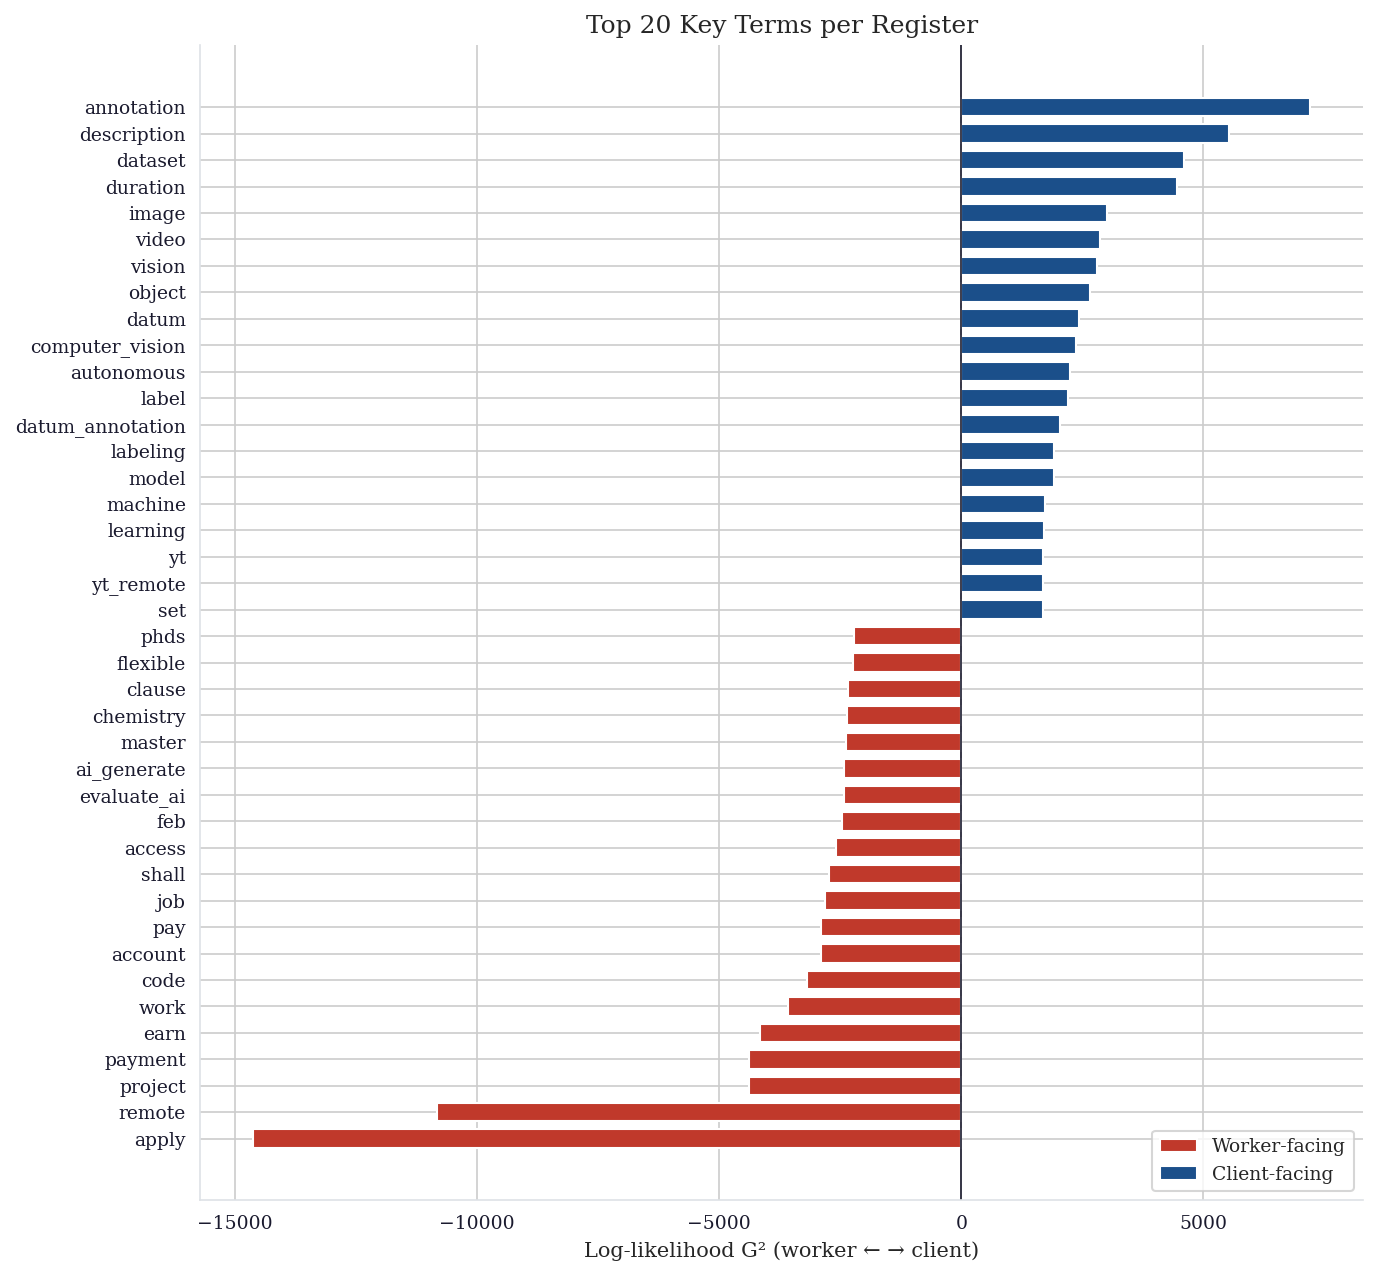

In [15]:
# ── §4.2.1c: Keyness Diverging Bar Chart (Figure 4.2) ─────────────────────

top_n = 20

w = pd.read_sql(f"""
    SELECT term, ll_score AS g2
    FROM keyness_results
    WHERE comparison = 'cross_platform'
      AND rel_freq_worker > 0
    ORDER BY ll_score ASC          -- most negative = most worker-key
    LIMIT {top_n}
""", conn)

c = pd.read_sql(f"""
    SELECT term, ll_score AS g2
    FROM keyness_results
    WHERE comparison = 'cross_platform'
      AND rel_freq_client > 0
    ORDER BY ll_score DESC         -- most positive = most client-key
    LIMIT {top_n}
""", conn)

# No sign flip needed — ll_score is already negative for worker-key terms
combined = pd.concat([w, c]).sort_values('g2')

fig, ax = plt.subplots(figsize=(10, 10))
colors = [C_WORKER if v < 0 else C_CLIENT for v in combined['g2']]
ax.barh(range(len(combined)), combined['g2'], color=colors, height=0.7)
ax.set_yticks(range(len(combined)))
ax.set_yticklabels(combined['term'], fontsize=9)
ax.axvline(0, color=C_TEXT, linewidth=0.8)
ax.set_xlabel('Log-likelihood G² (worker ← → client)', fontsize=10)
ax.set_title(f'Top {top_n} Key Terms per Register', fontsize=12)

legend_elements = [
    mpatches.Patch(facecolor=C_WORKER, label='Worker-facing'),
    mpatches.Patch(facecolor=C_CLIENT, label='Client-facing'),
]
ax.legend(handles=legend_elements, loc='lower right', fontsize=9)

apply_style(ax)
save_fig(fig, 'fig_42_keyness_diverging_bar')
plt.show()

### §4.2.2 — Term Exclusivity

Looks like you are using a tranform that doesn't support FancyArrowPatch, using ax.annotate instead. The arrows might strike through texts. Increasing shrinkA in arrowprops might help.


  Saved: ../output/chapter4/fig_43_exclusivity_volcano_final_v2.pdf


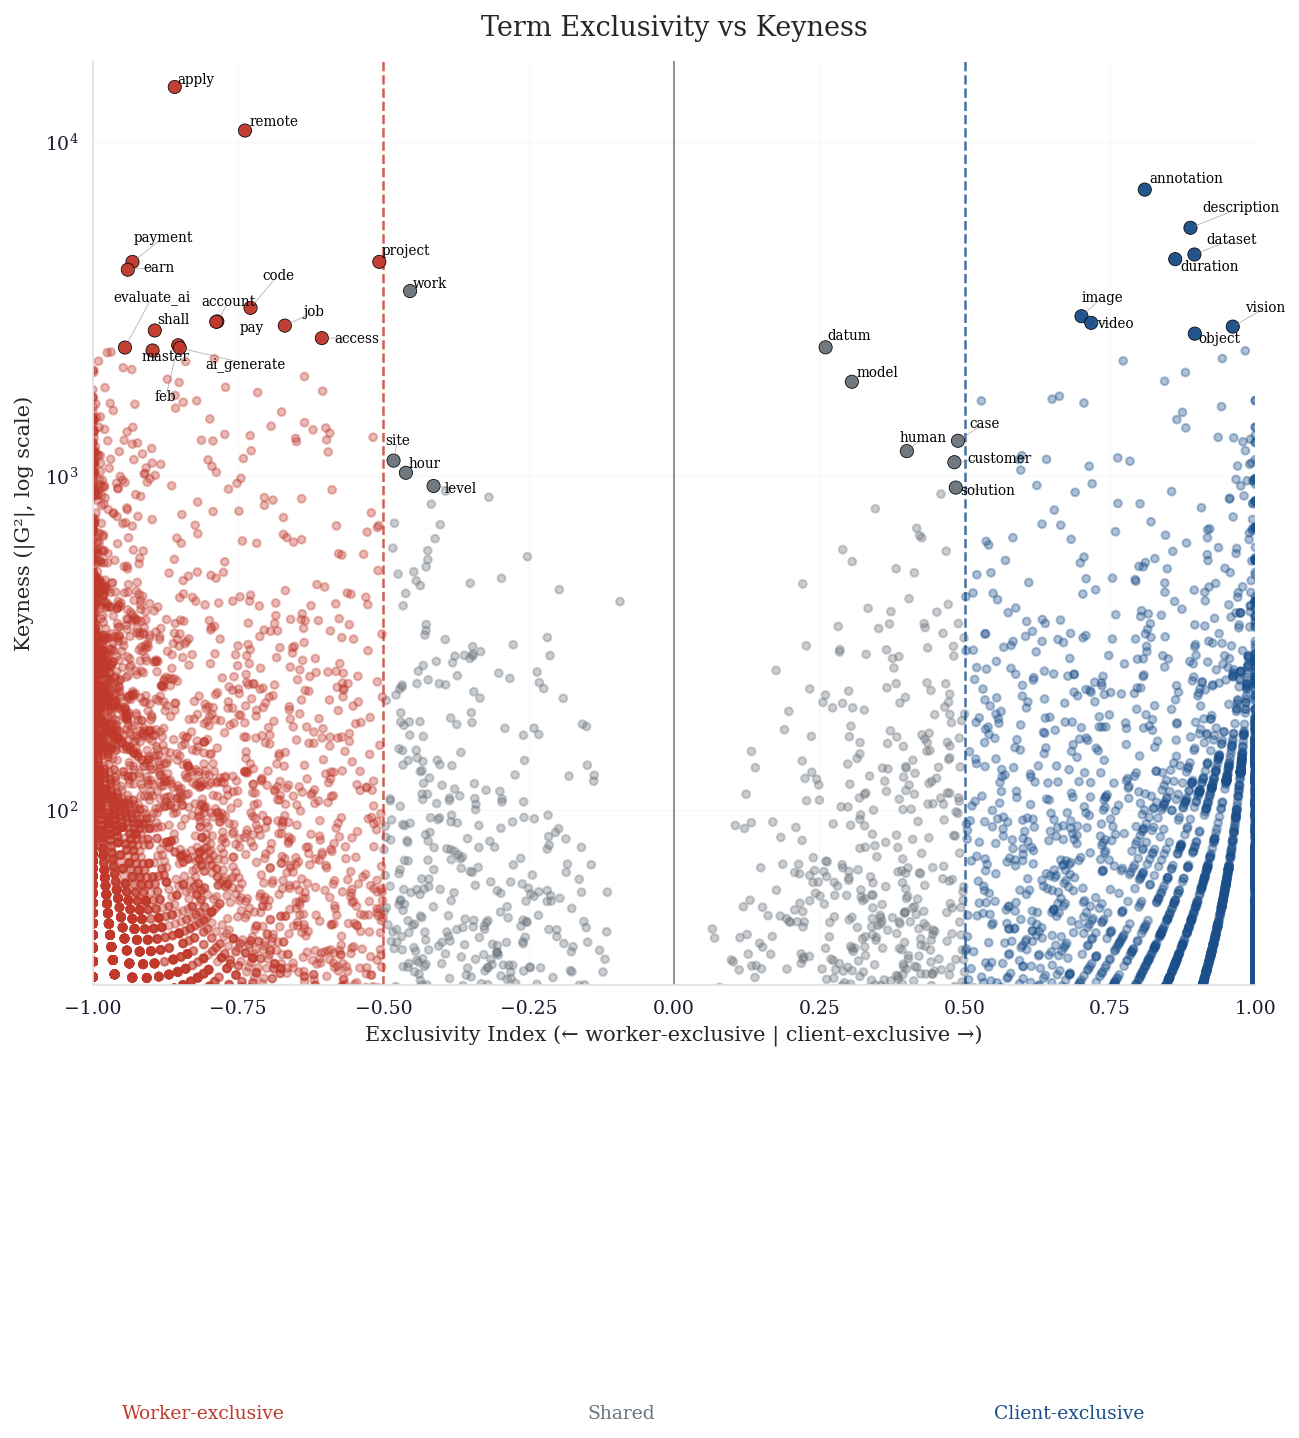


Terms with E < -0.5 (worker-exclusive): 14018
Terms with E > 0.5 (client-exclusive): 8982


In [5]:
# ── §4.x: Exclusivity Volcano Plot (Final Improved) ─────────────────

import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.ticker as ticker
from adjustText import adjust_text

# --- LOAD DATA ---
excl = pd.read_sql("""
    SELECT term,
           ll_score,
           rel_freq_worker,
           rel_freq_client,
           ROUND(
               (rel_freq_client - rel_freq_worker) /
               (rel_freq_worker + rel_freq_client), 4
           ) AS exclusivity_index,
           ABS(ll_score) AS g2_abs
    FROM keyness_results
    WHERE comparison = 'cross_platform'
      AND (rel_freq_worker + rel_freq_client) > 0
      AND ABS(ll_score) > 10
""", conn)

# --- LOG SAFETY ---
excl = excl[excl['g2_abs'] > 0]

# --- COLOR ASSIGNMENT ---
def get_color(x):
    if x < -0.5:
        return C_WORKER
    elif x > 0.5:
        return C_CLIENT
    else:
        return C_SHARED

excl['color'] = excl['exclusivity_index'].apply(get_color)

# --- LABEL SELECTION ---
top_g2 = excl.nlargest(25, 'g2_abs')

shared = excl[
    (excl['exclusivity_index'] >= -0.5) &
    (excl['exclusivity_index'] <= 0.5)
]
top_shared = shared.nlargest(10, 'g2_abs')

labels_df = pd.concat([top_g2, top_shared]).drop_duplicates()

# --- FIGURE ---
fig, ax = plt.subplots(figsize=(10, 8))

# --- ALL POINTS ---
ax.scatter(
    excl['exclusivity_index'],
    excl['g2_abs'],
    c=excl['color'],
    s=14,
    alpha=0.35,
    zorder=1
)

# --- HIGHLIGHTED POINTS ---
ax.scatter(
    labels_df['exclusivity_index'],
    labels_df['g2_abs'],
    c=labels_df['color'],
    s=40,
    alpha=0.95,
    edgecolor='black',
    linewidth=0.4,
    zorder=3
)

# --- LOG SCALE ---
ax.set_yscale('log')

# --- LABELS ---
texts = []
for _, row in labels_df.iterrows():
    texts.append(
        ax.text(
            row['exclusivity_index'],
            row['g2_abs'],
            row['term'],
            fontsize=6.5,
            color='black',
            zorder=4
        )
    )

# --- ADJUST LABELS ---
adjust_text(
    texts,
    arrowprops=dict(
        arrowstyle='-',
        color='gray',
        lw=0.4,
        alpha=0.6
    ),
    expand_points=(1.3, 1.5),
    expand_text=(1.3, 1.5),
    force_text=0.6
)

# --- REFERENCE LINES ---
ax.axvline(-0.5, color=C_WORKER, linewidth=1.2, linestyle='--', alpha=0.8)
ax.axvline(0.5,  color=C_CLIENT, linewidth=1.2, linestyle='--', alpha=0.8)
ax.axvline(0,    color='black', linewidth=0.8, alpha=0.5)

# --- THRESHOLD ---
ax.axhline(10, color='gray', linewidth=0.8, linestyle='--', alpha=0.6)

# --- REGION LABELS ---
ax.text(-0.95, 1.5, 'Worker-exclusive', fontsize=9, color=C_WORKER)
ax.text(0.55, 1.5, 'Client-exclusive', fontsize=9, color=C_CLIENT)
ax.text(-0.15, 1.5, 'Shared', fontsize=9, color=C_SHARED)

# --- AXES ---
ax.set_xlim(-1, 1)
ax.set_ylim(30, excl['g2_abs'].max() * 1.2)

ax.set_xlabel(
    'Exclusivity Index (← worker-exclusive | client-exclusive →)',
    fontsize=10
)
ax.set_ylabel('Keyness (|G²|, log scale)', fontsize=10)

ax.set_title(
    'Term Exclusivity vs Keyness',
    fontsize=13,
    pad=12
)

# --- LOG TICKS ---
ax.yaxis.set_major_locator(ticker.LogLocator(base=10))
ax.yaxis.set_minor_locator(ticker.LogLocator(base=10, subs='auto'))
ax.yaxis.set_minor_formatter(ticker.NullFormatter())

# --- GRID ---
ax.grid(True, which='major', linestyle='-', linewidth=0.4, alpha=0.2)
ax.grid(True, which='minor', linestyle=':', linewidth=0.3, alpha=0.15)

# --- CLEAN SPINES ---
ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)

# --- FREEZE AXIS ---
ax.autoscale(False)

# --- STYLE + SAVE ---
apply_style(ax)
save_fig(fig, 'fig_43_exclusivity_volcano_final_v2')

plt.show()

# --- STATS ---
n_worker_excl = len(excl[excl['exclusivity_index'] < -0.5])
n_client_excl = len(excl[excl['exclusivity_index'] > 0.5])

print(f'\nTerms with E < -0.5 (worker-exclusive): {n_worker_excl}')
print(f'Terms with E > 0.5 (client-exclusive): {n_client_excl}')

  Saved: ../output/chapter4/fig_43_exclusivity_volcano.pdf


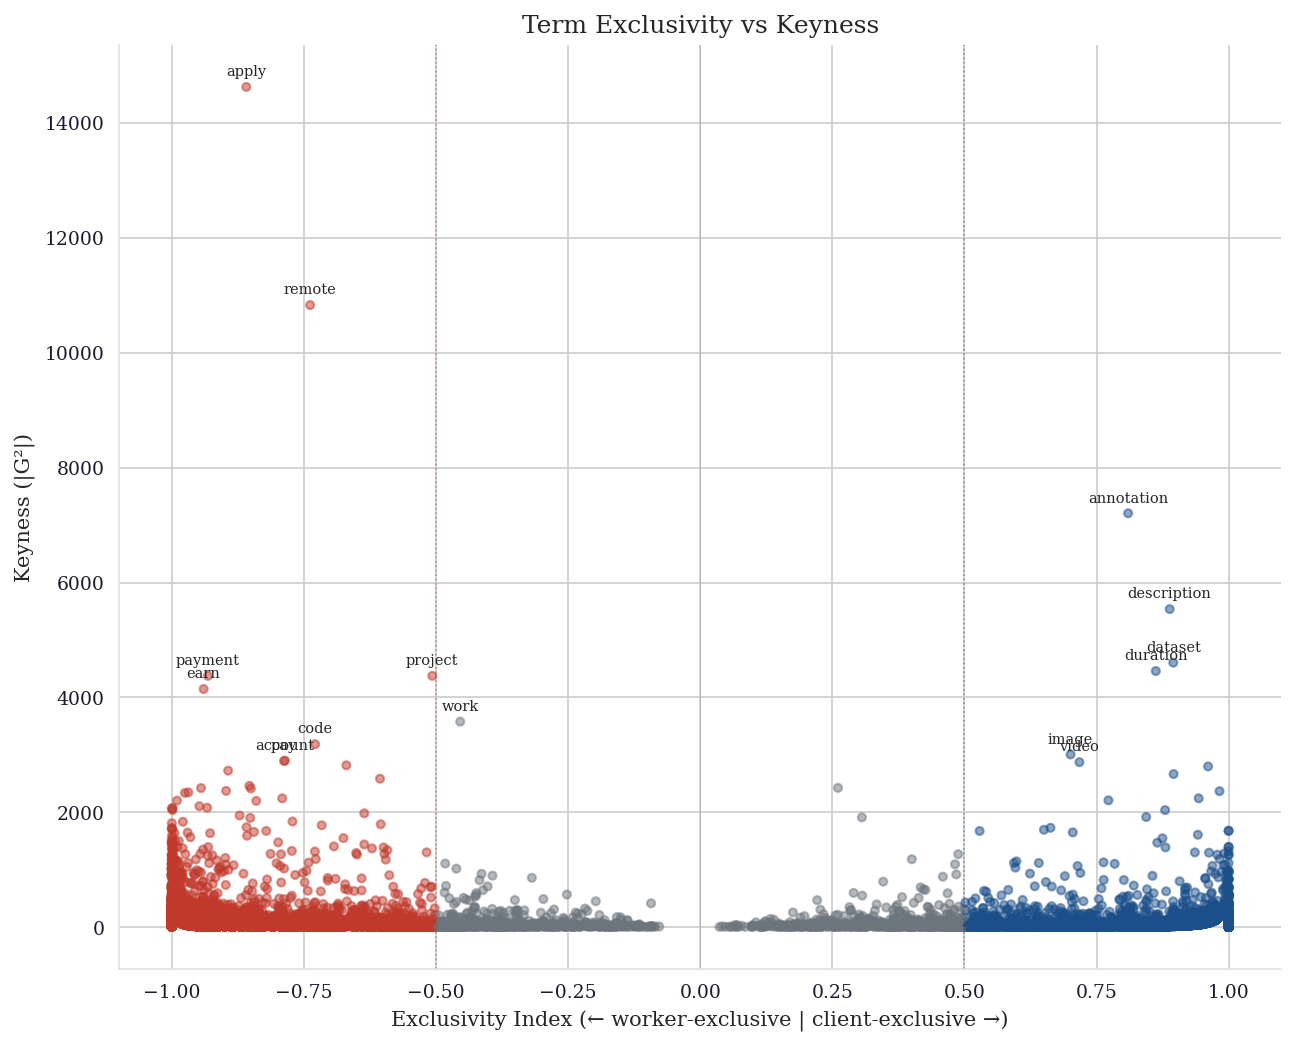


Terms with E < -0.5 (worker-exclusive): 14018
Terms with E > 0.5 (client-exclusive): 8982


In [17]:
# ── §4.x: Exclusivity Volcano Plot (Figure 4.3) ─────────────────────

excl = pd.read_sql("""
    SELECT term,
           ll_score,
           rel_freq_worker,
           rel_freq_client,
           ROUND(
               (rel_freq_client - rel_freq_worker) /
               (rel_freq_worker + rel_freq_client), 4
           ) AS exclusivity_index,
           ABS(ll_score) AS g2_abs
    FROM keyness_results
    WHERE comparison = 'cross_platform'
      AND (rel_freq_worker + rel_freq_client) > 0
      AND ABS(ll_score) > 10
""", conn)

fig, ax = plt.subplots(figsize=(10, 8))

colors = []
for _, row in excl.iterrows():
    if row['exclusivity_index'] < -0.5:
        colors.append(C_WORKER)
    elif row['exclusivity_index'] > 0.5:
        colors.append(C_CLIENT)
    else:
        colors.append(C_SHARED)

ax.scatter(excl['exclusivity_index'], excl['g2_abs'],
           c=colors, s=15, alpha=0.5, zorder=2)

# Label top terms by absolute keyness strength
top = excl.nlargest(15, 'g2_abs')
for _, row in top.iterrows():
    ax.annotate(row['term'], (row['exclusivity_index'], row['g2_abs']),
                fontsize=7, ha='center', va='bottom',
                xytext=(0, 4), textcoords='offset points')

ax.axvline(-0.5, color=C_WORKER, linewidth=0.8, linestyle=':', alpha=0.5)
ax.axvline(0.5,  color=C_CLIENT, linewidth=0.8, linestyle=':', alpha=0.5)
ax.axvline(0,    color=C_SHARED, linewidth=0.5, alpha=0.3)

ax.set_xlabel('Exclusivity Index (← worker-exclusive | client-exclusive →)', fontsize=10)
ax.set_ylabel('Keyness (|G²|)', fontsize=10)
ax.set_title('Term Exclusivity vs Keyness', fontsize=12)

apply_style(ax)
save_fig(fig, 'fig_43_exclusivity_volcano')
plt.show()

# Stats for text
n_worker_excl = len(excl[excl['exclusivity_index'] < -0.5])
n_client_excl = len(excl[excl['exclusivity_index'] > 0.5])
print(f'\nTerms with E < -0.5 (worker-exclusive): {n_worker_excl}')
print(f'Terms with E > 0.5 (client-exclusive): {n_client_excl}')

### §4.2.3 — Co-occurrence Analysis

The keyness and exclusivity analyses identified *which* terms diverge across
registers. Co-occurrence analysis addresses a different question: when the
two registers use the *same* term, do they activate the same semantic frame?
PMI profiles of a small set of anchor terms (`human`, `worker`, `work`, plus
automation seed terms) are compared across the client-facing and
worker-facing sub-corpora.

The purpose of this section is deliberately restricted. The PMI profiles are
treated here as *signposts* rather than as end-point interpretations: they
indicate which terms show the largest register divergence, and they identify
candidate pages for close reading in the Step-2 deep-reading analysis
(§4.4). Interpretation of individual collocates is deferred to that section,
where it can be grounded in KWIC passages and topic-model evidence.

Two simple filters are applied before plotting to guard against artefacts
identified in a preliminary diagnostic pass: a small blocklist of known
boilerplate / lemmatiser-truncation tokens (see `COOC_BLOCKLIST` in the
configuration cell), and a minimum-domain-diversity threshold requiring each
pair to appear across at least `COOC_MIN_DOMAINS` distinct platforms. The
combined filter strips out, for example, the eleven near-duplicate dataset
pages on humansintheloop.org whose shared licence footer had inflated
single-domain collocates of *human*.


In [ ]:
# ── §4.2.3a: PMI helper (with boilerplate / domain filter) ─────────────
# A single helper used by all co-occurrence cells in this section. The
# helper applies COOC_BLOCKLIST and COOC_MIN_DOMAINS from the config cell.

def _ensure_domain_support(rows, term, audience, min_domains):
    """Return rows where the (focus, collocate) pair appears across
    at least `min_domains` distinct domains. The supporting count is
    computed from the raw corpus_view token streams rather than from
    cooccurrence_results, so it works regardless of whether the
    upstream script stored per-domain counts."""
    if min_domains <= 1 or not rows:
        return rows
    collocs = [r['collocate'] for r in rows]
    placeholders = ','.join('?' * len(collocs))
    # Pull pages in the target audience containing the focus term.
    page_rows = conn.execute(f"""
        SELECT page_id, domain, tokens
        FROM corpus_view
        WHERE audience = ? AND tokens LIKE ?
    """, (audience, f'%{term}%')).fetchall()
    # For each candidate collocate, count distinct domains that host
    # both tokens (whole-token match).
    support = {c: set() for c in collocs}
    for pid, dom, toks_str in page_rows:
        toks = toks_str.split()
        if term not in toks:
            continue
        tset = set(toks)
        for c in collocs:
            if c in tset:
                support[c].add(dom)
    kept = [r for r in rows if len(support[r['collocate']]) >= min_domains]
    return kept


def get_pmi_profile(term, audience, top_n=10, min_len=3, min_cofreq=5,
                    apply_filter=True):
    """Top PMI collocates for `term` in `audience`, with boilerplate
    and domain-support filtering. Returns a pandas DataFrame."""
    # Pull a generous candidate pool so the filter has room to cut.
    pool = 3 * top_n
    rows = conn.execute("""
        SELECT collocate, pmi, cofreq
        FROM cooccurrence_results
        WHERE focus_term = ?
          AND audience   = ?
          AND comparison = 'cross_platform'
          AND LENGTH(collocate) >= ?
          AND cofreq     >= ?
        ORDER BY pmi DESC
        LIMIT ?
    """, (term, audience, min_len, min_cofreq, pool)).fetchall()
    rows = [dict(r) for r in rows]
    if apply_filter:
        rows = [r for r in rows if r['collocate'] not in COOC_BLOCKLIST]
        rows = _ensure_domain_support(rows, term, audience, COOC_MIN_DOMAINS)
    rows = rows[:top_n]
    return pd.DataFrame(rows, columns=['collocate', 'pmi', 'cofreq'])


def plot_pmi_comparison(term, client_df, worker_df, fig_name, top_n=None):
    fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 7), sharey=False)
    if len(client_df) > 0:
        ax1.barh(range(len(client_df)), client_df['pmi'],
                 color=C_CLIENT, height=0.7)
        ax1.set_yticks(range(len(client_df)))
        ax1.set_yticklabels(client_df['collocate'], fontsize=9)
        ax1.invert_yaxis()
    ax1.set_title(f'"{term}" — Client-facing', fontsize=11)
    ax1.set_xlabel('PMI', fontsize=10)
    apply_style(ax1)
    if len(worker_df) > 0:
        ax2.barh(range(len(worker_df)), worker_df['pmi'],
                 color=C_WORKER, height=0.7)
        ax2.set_yticks(range(len(worker_df)))
        ax2.set_yticklabels(worker_df['collocate'], fontsize=9)
        ax2.invert_yaxis()
    ax2.set_title(f'"{term}" — Worker-facing', fontsize=11)
    ax2.set_xlabel('PMI', fontsize=10)
    apply_style(ax2)
    fig.suptitle(f'Co-occurrence Profiles of "{term}" Across Registers',
                 fontsize=13, y=1.02)
    fig.tight_layout()
    save_fig(fig, fig_name)
    plt.show()


# Shared container for profiles — consumed by the sampling cell below.
COOC_PROFILES = {}


# ── Human ──────────────────────────────────────────────────────────────────
FOCUS_TERM = 'human'
COOC_N = 10
client_df = get_pmi_profile(FOCUS_TERM, 'client', COOC_N)
worker_df = get_pmi_profile(FOCUS_TERM, 'worker', COOC_N)
COOC_PROFILES[FOCUS_TERM] = {'client': client_df, 'worker': worker_df}
plot_pmi_comparison(FOCUS_TERM, client_df, worker_df, 'fig_44_cooc_human_comparison')


In [ ]:
# ── §4.2.3b: "worker" PMI Profile (filtered) ─────────────────────────────
FOCUS_TERM = 'worker'
COOC_N = 15
client_df = get_pmi_profile(FOCUS_TERM, 'client', COOC_N)
worker_df = get_pmi_profile(FOCUS_TERM, 'worker', COOC_N)
COOC_PROFILES[FOCUS_TERM] = {'client': client_df, 'worker': worker_df}
plot_pmi_comparison(FOCUS_TERM, client_df, worker_df, 'fig_44b_cooc_worker_comparison')


In [ ]:
# ── §4.2.3c: "work" PMI Profile (filtered) ───────────────────────────────
FOCUS_TERM = 'work'
COOC_N = 15
client_df = get_pmi_profile(FOCUS_TERM, 'client', COOC_N)
worker_df = get_pmi_profile(FOCUS_TERM, 'worker', COOC_N)
COOC_PROFILES[FOCUS_TERM] = {'client': client_df, 'worker': worker_df}
plot_pmi_comparison(FOCUS_TERM, client_df, worker_df, 'fig_44c_cooc_work_comparison')


In [ ]:
# ── §4.2.3d: Automation Terms PMI Profiles (filtered) ─────────────────────
AUTO_TERMS = ['intelligent', 'quality', 'task', 'product']

for term in AUTO_TERMS:
    client_prof = get_pmi_profile(term, 'client', 10)
    worker_prof = get_pmi_profile(term, 'worker', 10)
    if len(client_prof) == 0 and len(worker_prof) == 0:
        print(f'  No co-occurrence data for "{term}" — skipping')
        continue
    COOC_PROFILES[term] = {'client': client_prof, 'worker': worker_prof}
    print(f'\n=== "{term}" ===')
    if len(client_prof):
        print(f'  Client top: {", ".join(client_prof["collocate"].tolist()[:8])}')
    if len(worker_prof):
        print(f'  Worker top: {", ".join(worker_prof["collocate"].tolist()[:8])}')


#### §4.2.3e — From co-occurrence signposts to Step-2 sampling

The filtered PMI profiles above identify the register-divergent term pairs.
The cell below converts those profiles into a concrete sampling frame for
the Step-2 close reading (§4.4): for each top (focus, collocate, audience)
triple, it retrieves every page in which both tokens co-occur and writes a
CSV of candidate passages. This is the mechanism by which the exploratory
lexical results in §4.2 *constrain* the interpretive reading that follows,
rather than being interpreted in isolation here.


In [ ]:
# ── §4.2.3e: Sampling frame for Step 2 (close reading) ────────────────────
# For each (focus_term, collocate, audience) triple at the top of a profile,
# retrieve the pages where both tokens co-occur. This produces the candidate
# sampling frame for §4.4.
#
# Output: sampling_frame.csv with columns
#   focus_term, collocate, audience, rank, pmi, page_id, domain, url
# plus a summary count per triple.

SAMPLING_TOP_K = 5   # how many top collocates per (term, audience) to seed

def pages_with_pair(focus, coll, audience):
    rows = conn.execute("""
        SELECT page_id, domain, url, tokens
        FROM corpus_view
        WHERE audience = ?
          AND tokens LIKE ?
          AND tokens LIKE ?
    """, (audience, f'%{focus}%', f'%{coll}%')).fetchall()
    # Whole-token match.
    keep = []
    for r in rows:
        toks = r['tokens'].split()
        if focus in toks and coll in toks:
            keep.append({
                'page_id': r['page_id'],
                'domain': r['domain'],
                'url': r['url'],
            })
    return keep


frame_rows = []
summary_rows = []
for term, profiles in COOC_PROFILES.items():
    for audience, df in profiles.items():
        if df is None or len(df) == 0:
            continue
        for rank, (_, row) in enumerate(df.head(SAMPLING_TOP_K).iterrows(), 1):
            coll = row['collocate']
            pages = pages_with_pair(term, coll, audience)
            summary_rows.append({
                'focus_term': term,
                'collocate': coll,
                'audience': audience,
                'rank': rank,
                'pmi': round(float(row['pmi']), 3),
                'n_pages': len(pages),
                'n_domains': len({p['domain'] for p in pages}),
            })
            for p in pages:
                frame_rows.append({
                    'focus_term': term,
                    'collocate': coll,
                    'audience': audience,
                    'rank': rank,
                    'pmi': round(float(row['pmi']), 3),
                    **p,
                })

frame_df = pd.DataFrame(frame_rows)
summary_df = pd.DataFrame(summary_rows)

frame_path = FIG_DIR / 'sampling_frame.csv'
summary_path = FIG_DIR / 'sampling_frame_summary.csv'
frame_df.to_csv(frame_path, index=False)
summary_df.to_csv(summary_path, index=False)

print(f'Wrote {len(frame_df)} candidate passages -> {frame_path.name}')
print(f'Wrote {len(summary_df)} triples          -> {summary_path.name}')
print()
print('Top triples by rank (rank 1 in each audience):')
display(summary_df[summary_df['rank'] == 1]
        .sort_values(['focus_term', 'audience']))


---
## §4.3 — Thematic Structure: Structural Topic Model

In [12]:
# ── §4.3.0: Check STM tables exist ────────────────────────────────────────

stm_tables = {'stm_theta', 'stm_topic_terms', 'stm_prevalence'}
missing = stm_tables - tables
if missing:
    print(f'MISSING STM tables: {missing}')
    print('Run 03b_import_stm.py first.')
else:
    print('All STM tables present.')
    n_topics = conn.execute('SELECT COUNT(DISTINCT topic_id) FROM stm_topic_terms').fetchone()[0]
    print(f'Number of topics: {n_topics}')

All STM tables present.
Number of topics: 25


In [14]:
# ── §4.3.1: Full Topic Table (Table 4.X) ──────────────────────────────────
# The master table of the chapter: all 25 topics with FREX, estimate, CI

if 'stm_prevalence' in tables and 'stm_topic_terms' in tables:
    # Get prevalence estimates
    prev = pd.read_sql("""
        SELECT topic_id, frex_label, estimate, std_err,
               ci_lower, ci_upper, significant, direction
        FROM stm_prevalence
        ORDER BY estimate
    """, conn)
    
    # Get FREX terms per topic
    frex = pd.read_sql("""
        SELECT topic_id, GROUP_CONCAT(frex_term, ', ') AS frex_terms
        FROM (
            SELECT topic_id, frex_term
            FROM stm_topic_terms
            WHERE rank <= 7
            ORDER BY topic_id, rank
        )
        GROUP BY topic_id
    """, conn)
    
    topic_table = prev.merge(frex, on='topic_id', how='left')
    
    # Apply custom labels from 06_stm_results_figures.py
    TOPIC_LABELS = {
        1: 'Freelance AI training work',
        2: 'Survey & market research',
        3: 'NLP & text annotation',
        4: 'B2B outsourcing content',
        5: 'Technical AI evaluation tasks',
        6: 'AI governance & oversight',
        7: 'LLM evaluation & fine-tuning',
        8: 'Cookie & tracking notices',
        9: 'Computer vision labeling',
        10: 'Privacy policy & terms of service',
        11: 'Worker payments & earnings',
        12: 'Annotation platform tools',
        13: 'Government & compliance hiring',
        14: 'Expert specialist recruitment',
        15: 'Enterprise partnerships',
        16: 'B2B workforce solutions',
        17: 'Annotation API & developer tools',
        18: 'Human-AI discourse',
        19: 'Speech & audio data collection',
        20: 'Autonomous vehicles & drone sensing',
        21: 'AI deployment & synthetic data',
        22: 'Microwork platform campaigns',
        23: 'Medical image annotation',
        24: 'Search relevance & content tagging',
        25: 'Machine learning concepts',
    }
    topic_table['label'] = topic_table['topic_id'].map(TOPIC_LABELS)
    topic_table['label'] = topic_table['label'].fillna(topic_table['frex_label'])
    
    # ── HYPOTHESIS CLASSIFICATION ─────────────────────────────────────────-
    TOPIC_HYPOTHESIS = {
        1:  'H1a',   # Freelance AI training work
        2:  'H1a',   # Survey & market research
        3:  'H1a',   # NLP & text annotation
        4:  'H1a',   # B2B outsourcing content
        5:  'H1b',   # Technical AI evaluation tasks
        6:  'H1c',   # AI governance & oversight
        7:  'H1a',   # LLM evaluation & fine-tuning
        8:  None,   # Cookie & tracking notices
        9:  'H1a',   # Computer vision labeling
        10: None,   # Privacy policy & terms of service
        11: 'H1a',   # Worker payments & earnings
        12: 'H1b',   # Annotation platform tools
        13: 'H1a',   # Government & compliance hiring
        14: 'H1c',   # Expert specialist recruitment
        15: None,   # Enterprise partnerships
        16: 'H1c',   # B2B workforce solutions
        17: 'H1b',   # Annotation API & developer tools
        18: 'H1a',   # Human-AI discourse
        19: 'H1b',   # Speech & audio data collection
        20: 'H1b',   # Autonomous vehicles & drone sensing
        21: 'H1a',   # AI deployment & synthetic data
        22: 'H1a',   # Microwork platform campaigns
        23: 'H1a',   # Medical image annotation
        24: 'H1c',   # Search relevance & content tagging
        25: 'H1a',   # Machine learning concepts
    }
    topic_table['hypothesis'] = topic_table['topic_id'].map(TOPIC_HYPOTHESIS)
    
    print('=== Full Topic Table (sorted by estimate) ===')
    display_cols = ['topic_id', 'label', 'frex_terms', 'estimate',
                    'ci_lower', 'ci_upper', 'significant', 'hypothesis']
    print(topic_table[display_cols].to_string(index=False))
else:
    print('STM tables not available.')

=== Full Topic Table (sorted by estimate) ===
 topic_id                               label                                                                 frex_terms  estimate  ci_lower  ci_upper  significant hypothesis
       12           Annotation platform tools               vetted, labeler, freelancer, hire, manage, trainers, pricing -0.067918 -0.083220 -0.052616            1        H1b
       16             B2B workforce solutions                 workforce, market, client, utm, house, deliver, investment -0.065678 -0.075282 -0.056074            1        H1c
        6           AI governance & oversight                   ethical, utm, risk, defense, oversight, financial, fraud -0.048842 -0.058755 -0.038929            1        H1c
        9            Computer vision labeling                   segmentation, box, bounding, image, object, pixel, frame -0.044604 -0.052953 -0.036255            1        H1a
       20 Autonomous vehicles & drone sensing                       drone, lida

  Saved: ../output/chapter4/fig_46_stm_prevalence_forest.pdf


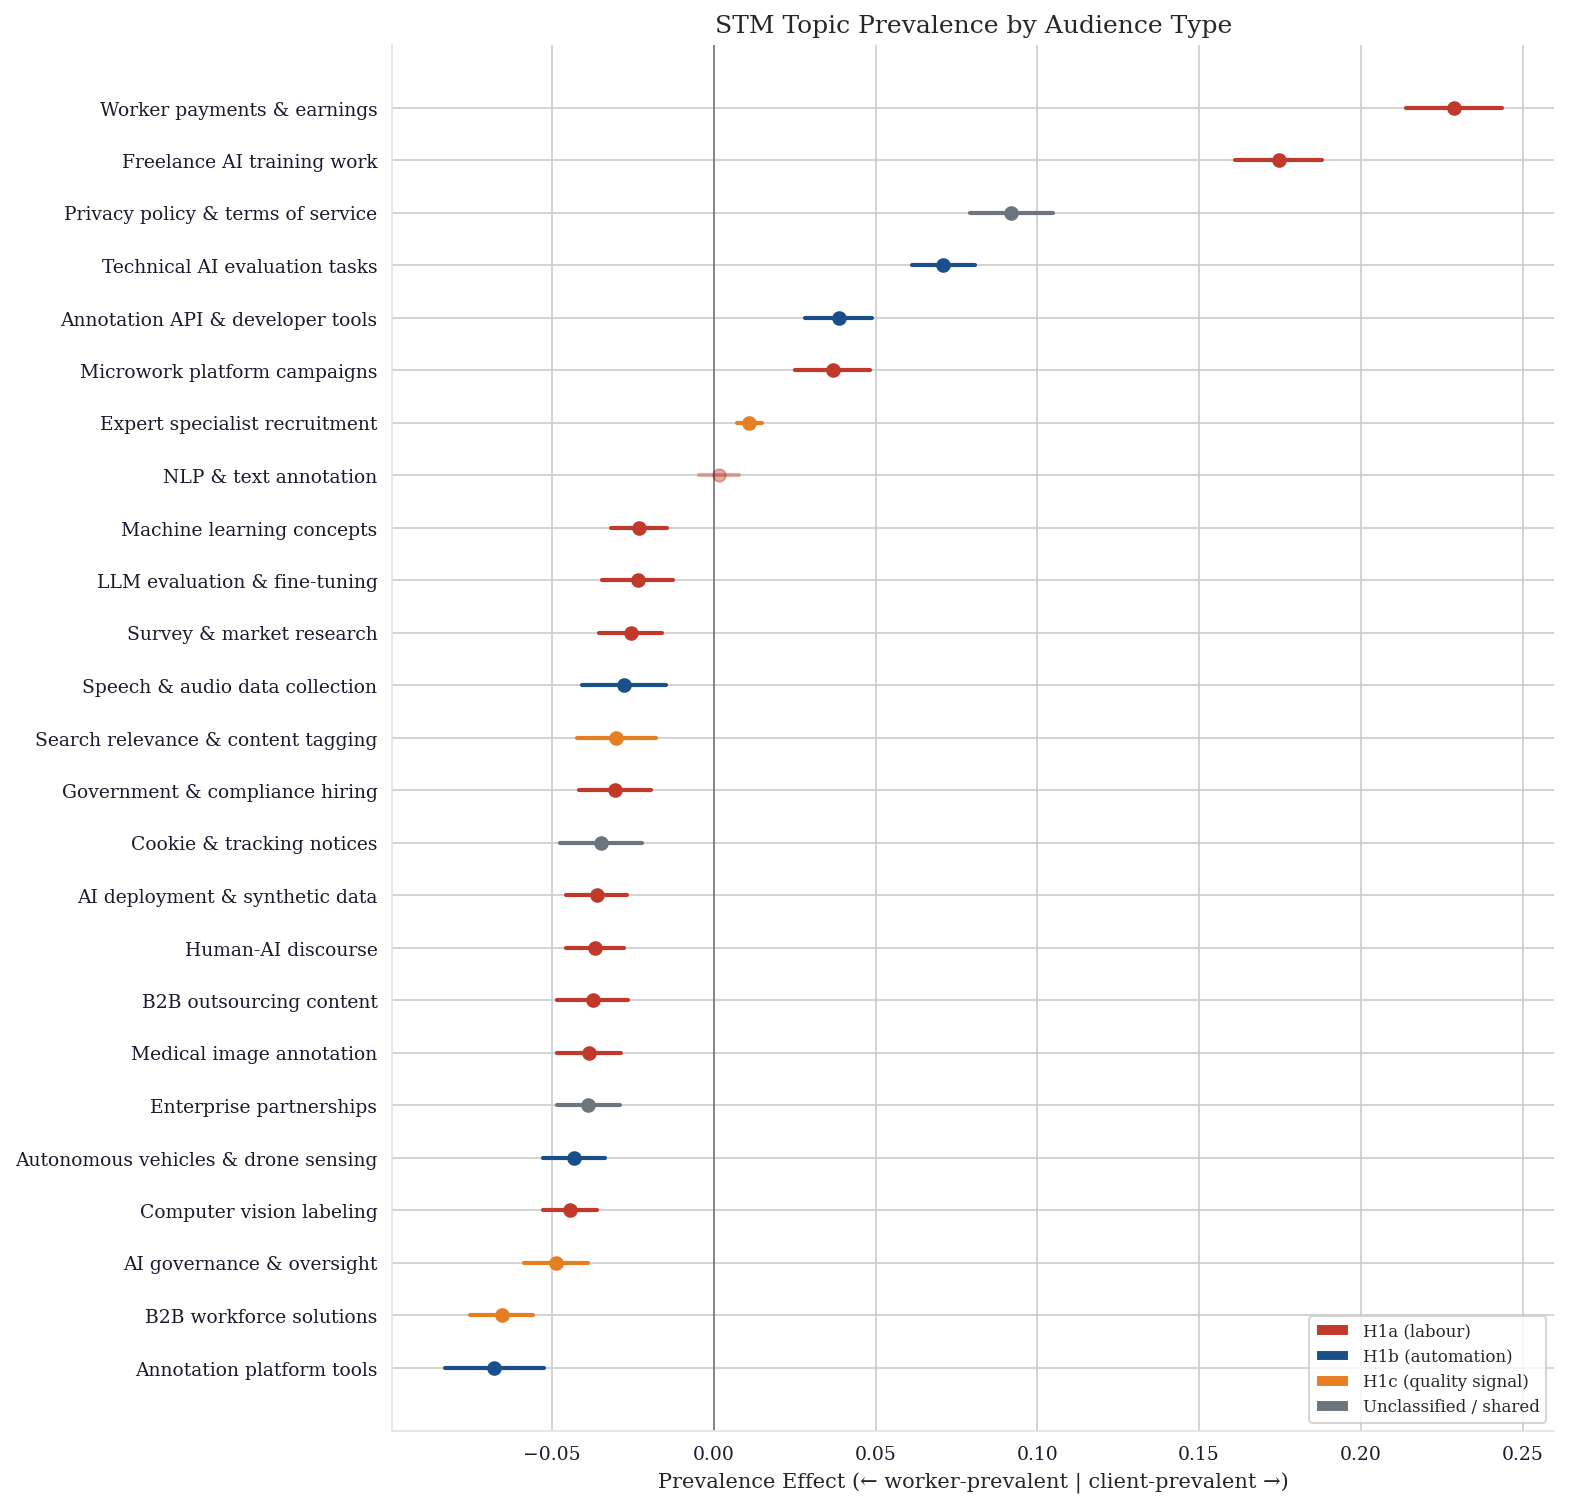

In [15]:
# ── §4.3.2: STM Prevalence Forest Plot (Figure 4.6) ───────────────────────
# All 25 topics sorted by estimate, with 95% CI, coloured by direction

if 'stm_prevalence' in tables:
    prev = pd.read_sql("""
        SELECT topic_id, estimate, ci_lower, ci_upper, significant
        FROM stm_prevalence ORDER BY estimate
    """, conn)
    
    prev['label'] = prev['topic_id'].map(TOPIC_LABELS)
    prev['hyp'] = prev['topic_id'].map(TOPIC_HYPOTHESIS)
    
    fig, ax = plt.subplots(figsize=(10, 12))
    
    for i, (_, row) in enumerate(prev.iterrows()):
        color = PAL_HYP.get(row['hyp'], C_SHARED)
        alpha = 1.0 if row['significant'] else 0.4
        ax.plot([row['ci_lower'], row['ci_upper']], [i, i],
                color=color, linewidth=2, alpha=alpha)
        ax.plot(row['estimate'], i, 'o', color=color,
                markersize=6, alpha=alpha)
    
    ax.axvline(0, color=C_TEXT, linewidth=0.8, linestyle='-', alpha=0.5)
    ax.set_yticks(range(len(prev)))
    ax.set_yticklabels(prev['label'], fontsize=8)
    ax.set_xlabel('Prevalence Effect (← worker-prevalent | client-prevalent →)',
                  fontsize=10)
    ax.set_title('STM Topic Prevalence by Audience Type', fontsize=12)
    
    # Legend
    legend_elements = [
        mpatches.Patch(facecolor=C_WORKER, label='H1a (labour)'),
        mpatches.Patch(facecolor=C_CLIENT, label='H1b (automation)'),
        mpatches.Patch(facecolor=C_H1C, label='H1c (quality signal)'),
        mpatches.Patch(facecolor=C_SHARED, label='Unclassified / shared'),
    ]
    ax.legend(handles=legend_elements, loc='lower right', fontsize=8)
    
    apply_style(ax)
    save_fig(fig, 'fig_46_stm_prevalence_forest')
    plt.show()

  Saved: ../output/chapter4/fig_47_topic_cooccurrence_network.pdf


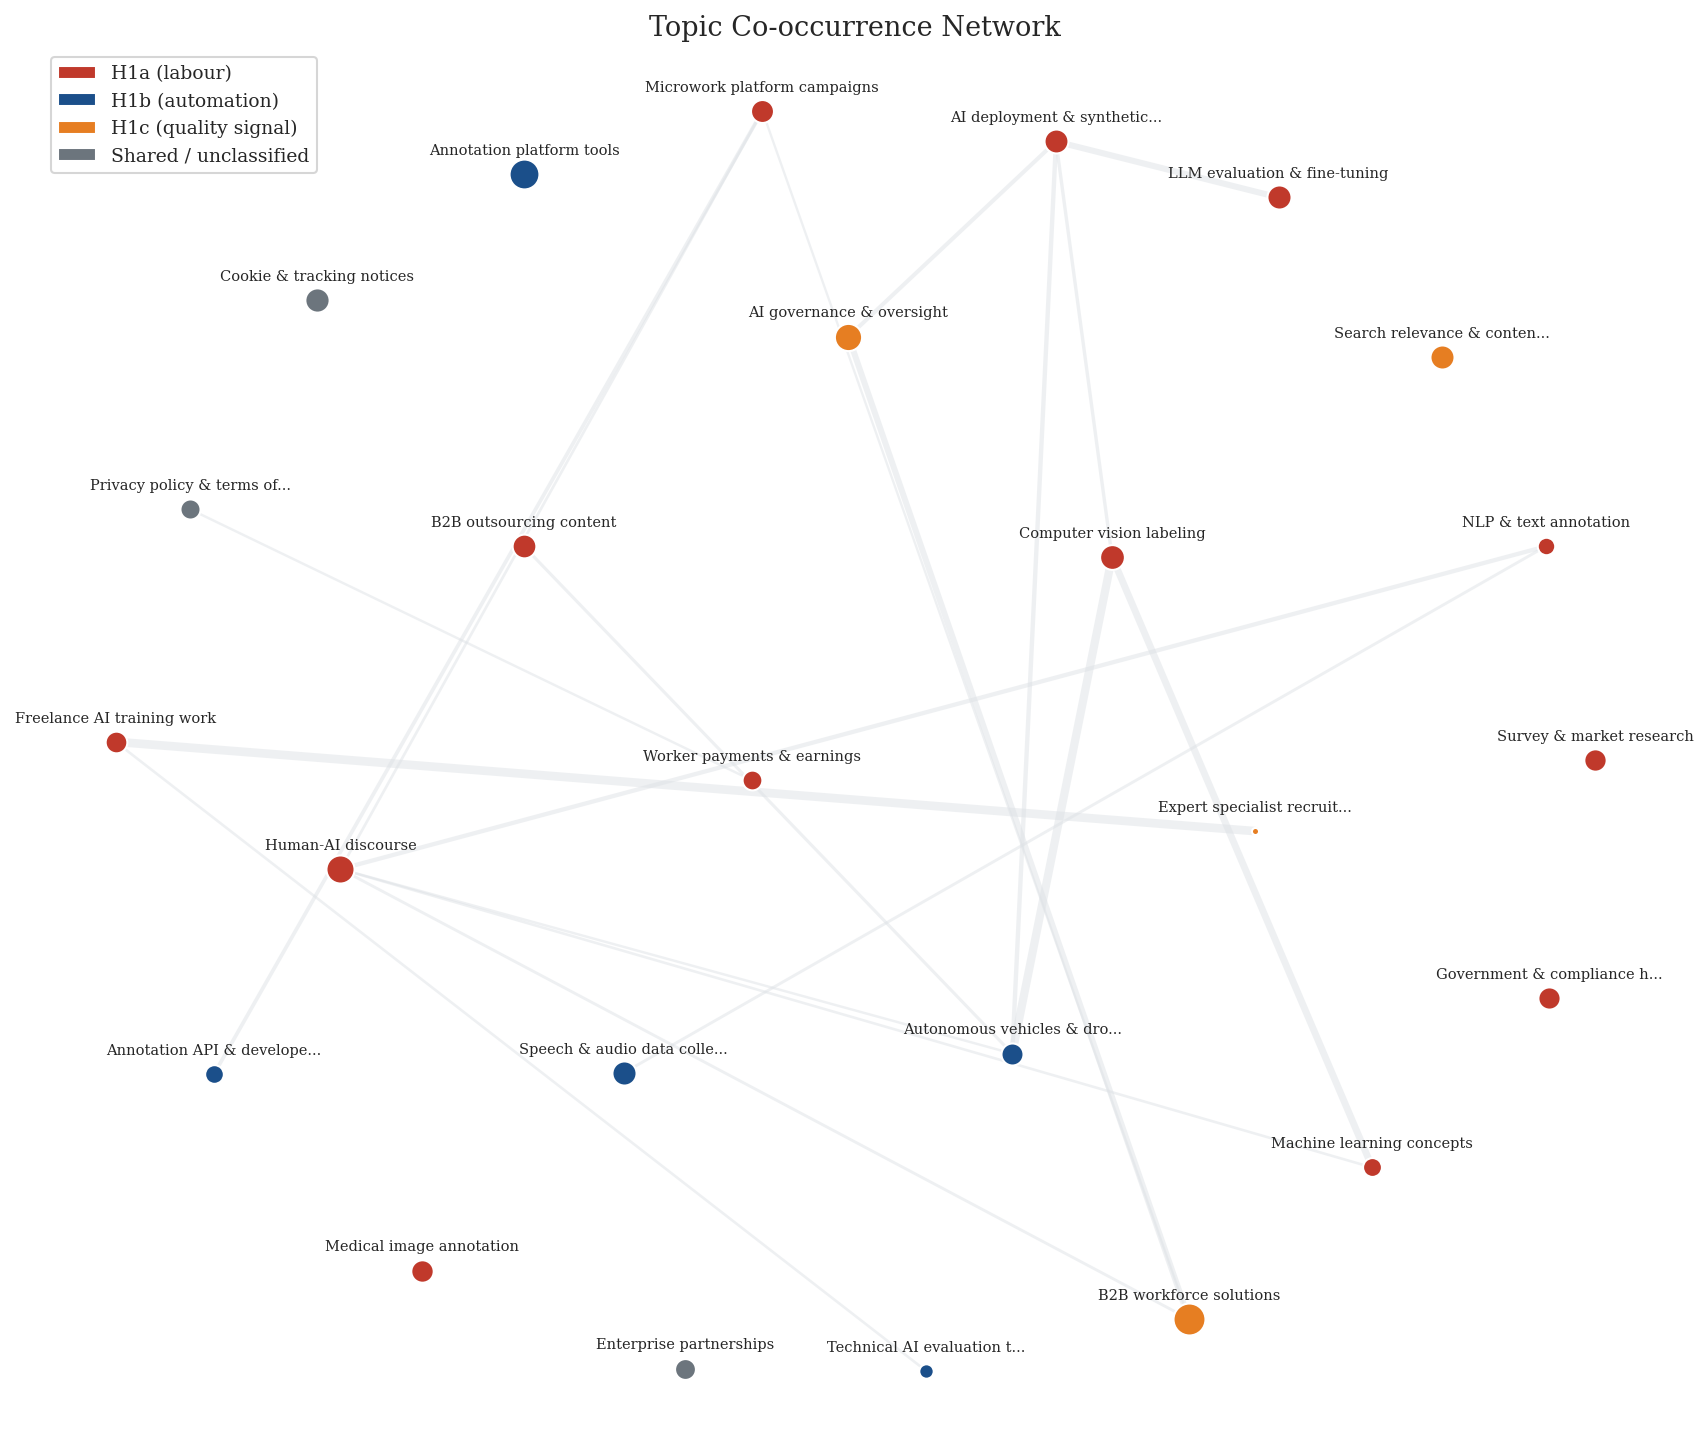

Network: 25 nodes, 19 edges (threshold ρ > 0.05)


In [21]:
# ── §4.3.3: Topic Co-occurrence Network (Figure 4.7) ──────────────────────
# NEW FIGURE — computes topic-topic correlations from stm_theta

if 'stm_theta' in tables and _HAS_NX:
    # Build document-topic matrix
    theta_df = pd.read_sql("""
        SELECT page_id, topic_id, theta
        FROM stm_theta
    """, conn)
    
    theta_wide = theta_df.pivot(index='page_id', columns='topic_id', values='theta')
    
    # Compute topic-topic correlation matrix
    corr = theta_wide.corr()
    
    # Build network: edges where correlation > threshold
    CORR_THRESHOLD = 0.05
    
    G = nx.Graph()
    for tid in corr.columns:
        G.add_node(tid)
    
    for i in corr.columns:
        for j in corr.columns:
            if i < j and corr.loc[i, j] > CORR_THRESHOLD:
                G.add_edge(i, j, weight=corr.loc[i, j])
    
    # Node attributes
    mean_prev = theta_wide.mean()
    
    # Layout
    #pos = nx.spring_layout(G, k=2.5, seed=42, weight='weight')
    #pos = nx.planar_layout(G)
    pos = nx.arf_layout(G)
    
    fig, ax = plt.subplots(figsize=(14, 12))
    
    # Draw edges
    for (u, v, d) in G.edges(data=True):
        ax.plot([pos[u][0], pos[v][0]], [pos[u][1], pos[v][1]],
                color=C_GRID, linewidth=d['weight'] * 20, alpha=0.5)
    
    # Draw nodes
    for tid in G.nodes:
        hyp = TOPIC_HYPOTHESIS.get(tid)
        color = PAL_HYP.get(hyp, C_SHARED)
        size = mean_prev.get(tid, 0.04) * 3000
        ax.scatter(pos[tid][0], pos[tid][1], s=size, c=color,
                   edgecolors='white', linewidth=1, zorder=3)
        label = TOPIC_LABELS.get(tid, f'T{tid}')
        # Shorten label
        short = label[:25] + '...' if len(label) > 28 else label
        ax.annotate(short, pos[tid], fontsize=7, ha='center', va='bottom',
                    xytext=(0, 8), textcoords='offset points')
    
    ax.set_title('Topic Co-occurrence Network', fontsize=13)
    ax.axis('off')
    
    legend_elements = [
        mpatches.Patch(facecolor=C_WORKER, label='H1a (labour)'),
        mpatches.Patch(facecolor=C_CLIENT, label='H1b (automation)'),
        mpatches.Patch(facecolor=C_H1C, label='H1c (quality signal)'),
        mpatches.Patch(facecolor=C_SHARED, label='Shared / unclassified'),
    ]
    ax.legend(handles=legend_elements, loc='upper left', fontsize=9)
    
    save_fig(fig, 'fig_47_topic_cooccurrence_network')
    plt.show()
    
    print(f'Network: {G.number_of_nodes()} nodes, {G.number_of_edges()} edges '
          f'(threshold ρ > {CORR_THRESHOLD})')
elif not _HAS_NX:
    print('SKIP: networkx not installed. Run: pip install networkx')
else:
    print('SKIP: stm_theta not in DB.')

---
## §4.4 — Interpretive Synthesis: H1a–H1c with Close Reading

This section does not produce new figures but **selects and re-presents** evidence from §4.2–4.3, supplemented by close reading passages.  
The cells below extract the specific numbers and passages needed.

In [ ]:
# ── §4.4.1: H1a Evidence Summary ──────────────────────────────────────────
# Pull together: labour keyness terms, exclusivity stats, STM labour topics

print('=== H1a: Labour Visibility Gap ===')
print()

# Key labour terms in worker register
labour_terms = pd.read_sql("""
    SELECT term, g2, freq_worker_pmw, freq_client_pmw, exclusivity
    FROM keyness_results
    WHERE direction = 'worker'
      AND term IN ('worker', 'task', 'earn', 'annotator', 'qualify',
                   'apply', 'payment', 'job', 'project', 'gig')
    ORDER BY  DESC
""", conn)
print('Key labour terms (worker register):')
print(labour_terms.to_string(index=False))

# How many labour terms have E < -0.5?
if 'term_exclusivity' in tables:
    n_excl = conn.execute("""
        SELECT COUNT(*) FROM term_exclusivity
        WHERE exclusivity_index < -0.5
    """).fetchone()[0]
    print(f'\nTerms with E < -0.5 (worker-exclusive): {n_excl}')

# STM labour topics
if 'stm_prevalence' in tables:
    h1a_topics = [tid for tid, h in TOPIC_HYPOTHESIS.items() if h == 'H1a']
    if h1a_topics:
        placeholders = ','.join('?' * len(h1a_topics))
        h1a_prev = pd.read_sql(f"""
            SELECT topic_id, estimate, ci_lower, ci_upper, significant
            FROM stm_prevalence
            WHERE topic_id IN ({placeholders})
            ORDER BY estimate
        """, conn, params=h1a_topics)
        h1a_prev['label'] = h1a_prev['topic_id'].map(TOPIC_LABELS)
        print('\nH1a-classified STM topics:')
        print(h1a_prev.to_string(index=False))
    else:
        print('\n⚠️ No topics classified as H1a yet — fill TOPIC_HYPOTHESIS above.')

=== H1a: Labour Visibility Gap ===



DatabaseError: Execution failed on sql '
    SELECT term, g2, freq_worker_pmw, freq_client_pmw, exclusivity
    FROM keyness_results
    WHERE direction = 'worker'
      AND term IN ('worker', 'task', 'earn', 'annotator', 'qualify',
                   'apply', 'payment', 'job', 'project', 'gig')
    ORDER BY g2 DESC
': no such column: g2

In [ ]:
# ── §4.4.2: H1b Evidence Summary ──────────────────────────────────────────

print('=== H1b: Automation Narrative ===')
print()

# Client keyness: automation terms
auto_terms = pd.read_sql("""
    SELECT term, g2, freq_client_pmw, freq_worker_pmw, exclusivity
    FROM keyness_results
    WHERE direction = 'client'
      AND term IN ('model', 'solution', 'ai', 'pipeline', 'deploy',
                   'automate', 'algorithm', 'intelligent', 'autonomous')
    ORDER BY g2 DESC
""", conn)
print('Key automation terms (client register):')
print(auto_terms.to_string(index=False))

# Co-occurrence decoupling: top collocates of 'automate' in client register
auto_cooc = get_pmi_profile('automate', 'client', 10)
if len(auto_cooc) > 0:
    print(f'\nTop collocates of "automate" in client register:')
    print(auto_cooc.to_string(index=False))
    # Check if any are labour terms
    labour_set = {'worker', 'annotator', 'task', 'earn', 'human', 'labour', 'job'}
    overlap = set(auto_cooc['collocate']) & labour_set
    print(f'Labour terms among top collocates: {overlap if overlap else "NONE"}')

In [ ]:
# ── §4.4.3: H1c Evidence Summary ──────────────────────────────────────────

print('=== H1c: Strategic Hypervisibility ===')
print()

# "human" keyness in client register
human_key = pd.read_sql("""
    SELECT term, g2, freq_client_pmw, freq_worker_pmw, exclusivity
    FROM keyness_results
    WHERE term = 'human'
""", conn)
print('Keyness of "human":')
print(human_key.to_string(index=False))

# "human_in_the_loop" if it exists
hitl = pd.read_sql("""
    SELECT term, g2, freq_client_pmw, freq_worker_pmw, exclusivity
    FROM keyness_results
    WHERE term LIKE '%human%loop%'
""", conn)
if len(hitl) > 0:
    print('\n"human-in-the-loop" compound:')
    print(hitl.to_string(index=False))

# Recap: human co-occurrence divergence (already shown in §4.2.3)
print('\n(See Figure 4.4 for "human" PMI comparison)')

# H1c STM topic
h1c_topics = [tid for tid, h in TOPIC_HYPOTHESIS.items() if h == 'H1c']
if h1c_topics and 'stm_prevalence' in tables:
    placeholders = ','.join('?' * len(h1c_topics))
    h1c_prev = pd.read_sql(f"""
        SELECT topic_id, estimate, ci_lower, ci_upper, significant
        FROM stm_prevalence
        WHERE topic_id IN ({placeholders})
    """, conn, params=h1c_topics)
    h1c_prev['label'] = h1c_prev['topic_id'].map(TOPIC_LABELS)
    print('\nH1c-classified STM topics:')
    print(h1c_prev.to_string(index=False))
else:
    print('\n⚠️ No topics classified as H1c yet.')

In [ ]:
# ── §4.4: KWIC / Close Reading Passages ───────────────────────────────────
# Retrieve highest-θ documents for hypothesis-classified topics
# for use in close reading

KWIC_N = 3  # passages per topic

for hyp_label in ['H1a', 'H1b', 'H1c']:
    topics = [tid for tid, h in TOPIC_HYPOTHESIS.items() if h == hyp_label]
    if not topics:
        print(f'\n{hyp_label}: no topics classified — skipping')
        continue
    
    print(f'\n{"="*60}')
    print(f'{hyp_label} — Top passages from highest-θ documents')
    print(f'{"="*60}')
    
    for tid in topics:
        label = TOPIC_LABELS.get(tid, f'Topic {tid}')
        print(f'\n--- Topic {tid}: {label} ---')
        
        # Get top documents by theta for this topic
        if 'stm_topic_profile' in tables:
            docs = conn.execute("""
                SELECT p.page_id, p.audience, p.domain, p.theta
                FROM stm_topic_profile p
                WHERE p.topic_id = ?
                ORDER BY p.theta DESC
                LIMIT ?
            """, (tid, KWIC_N)).fetchall()
        elif 'stm_theta' in tables:
            docs = conn.execute("""
                SELECT t.page_id, c.audience, c.domain, t.theta
                FROM stm_theta t
                JOIN corpus_view c ON t.page_id = c.page_id
                WHERE t.topic_id = ?
                ORDER BY t.theta DESC
                LIMIT ?
            """, (tid, KWIC_N)).fetchall()
        else:
            docs = []
        
        for doc in docs:
            page_id, audience, domain, theta = doc
            # Get first 500 chars of text
            text = conn.execute("""
                SELECT SUBSTR(text_content, 1, 500) FROM pages
                WHERE page_id = ?
            """, (page_id,)).fetchone()
            snippet = text[0] if text else '[no text]'
            print(f'  [{audience}] {domain} (θ={theta:.3f})')
            print(f'  {snippet[:300]}...')
            print()

In [ ]:
# ── Cleanup ────────────────────────────────────────────────────────────────
conn.close()
print('Database connection closed.')
print(f'\nAll figures saved to: {FIG_DIR}/')
print('\nFigure inventory:')
for f in sorted(FIG_DIR.glob('*')):
    print(f'  {f.name}')